# Membrane Channel — Registration Error Over Time (GM vs PP v2)

Comparison of GM (getMotion, zRatio=10) and PP v2 (Phase Persist, fixed).
Metrics computed on **foreground pixels only**, normalized to [0, 255].

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load GM and PP v2 metrics
GM_CSV  = Path("/mnt/data21T_2/cyf/f260517/GM_mapped_v2_layer3/metrics.csv")
PP_CSV  = Path("/mnt/data21T_2/cyf/f260517/PP_baseline_l3/metrics.csv")
OUT_DIR = Path("/home/cyf/wbi/Virginia/code_for_paper/Fig3")

df_gm = pd.read_csv(GM_CSV)
df_pp = pd.read_csv(PP_CSV)
frames = df_gm["frame"].values

# Smoothing helper
def smooth(series, window=5):
    return series.rolling(window, center=True, min_periods=1).mean()

print(f"GM:  {len(df_gm)} frames  |  PP v2: {len(df_pp)} frames")
print(f"GM  mem_GradNCC mean: {df_gm['mem_GradNCC'].mean():.4f}")
print(f"PP  mem_GradNCC mean: {df_pp['mem_GradNCC'].mean():.4f}")

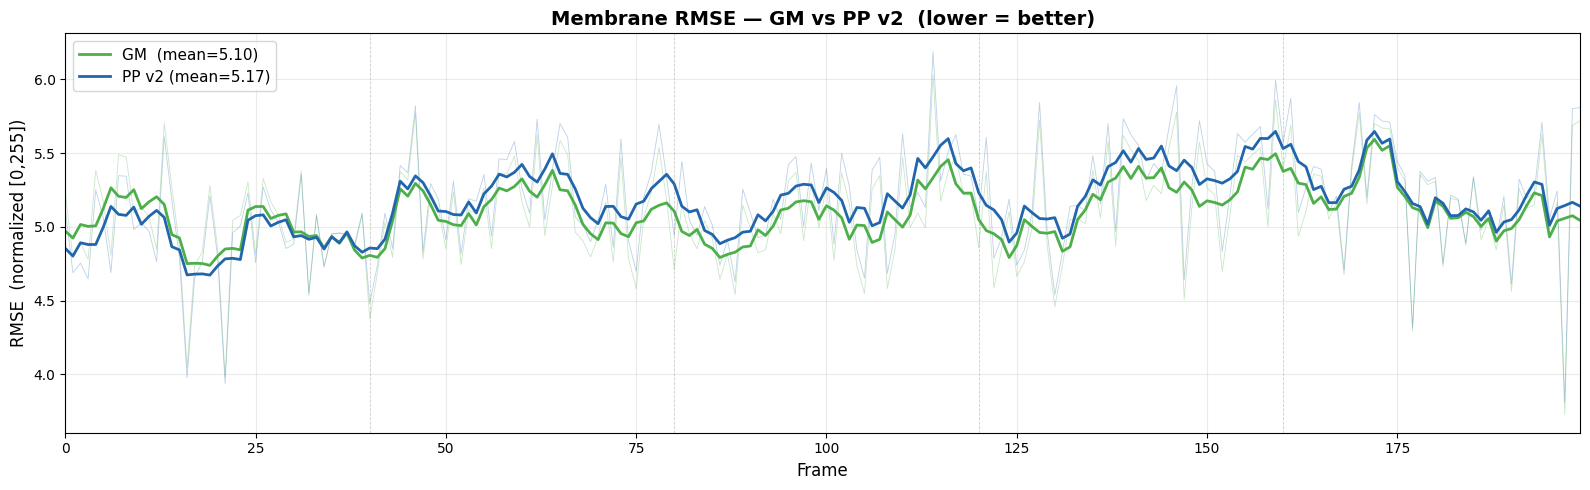

Saved to membrane_RMSE_GM_vs_PPv2.png


In [5]:
# ================================================================
# Figure 1: Membrane RMSE — GM vs PP v2
# ================================================================
WINDOW = 5
c_gm = "#4DAF4A"   # green
c_pp = "#2166AC"   # blue

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(frames, df_gm["mem_RMSE"], color=c_gm, lw=0.6, alpha=0.3)
ax.plot(frames, df_pp["mem_RMSE"], color=c_pp, lw=0.6, alpha=0.3)
ax.plot(frames, smooth(df_gm["mem_RMSE"], WINDOW), color=c_gm, lw=2.0, label=f"GM  (mean={df_gm['mem_RMSE'].mean():.2f})")
ax.plot(frames, smooth(df_pp["mem_RMSE"], WINDOW), color=c_pp, lw=2.0, label=f"PP v2 (mean={df_pp['mem_RMSE'].mean():.2f})")

for rf in [40, 80, 120, 160]:
    ax.axvline(x=rf, color="gray", lw=0.6, ls="--", alpha=0.4)

ax.set_ylabel("RMSE  (normalized [0,255])", fontsize=12)
ax.set_xlabel("Frame", fontsize=12)
ax.set_title("Membrane RMSE — GM vs PP v2  (lower = better)", fontsize=14, fontweight="bold")
ax.legend(fontsize=11, loc="upper left")
ax.grid(True, alpha=0.25)
ax.set_xlim(0, 199)

fig.tight_layout()
fig.savefig(str(OUT_DIR / "membrane_RMSE_GM_vs_PPv2.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved to membrane_RMSE_GM_vs_PPv2.png")

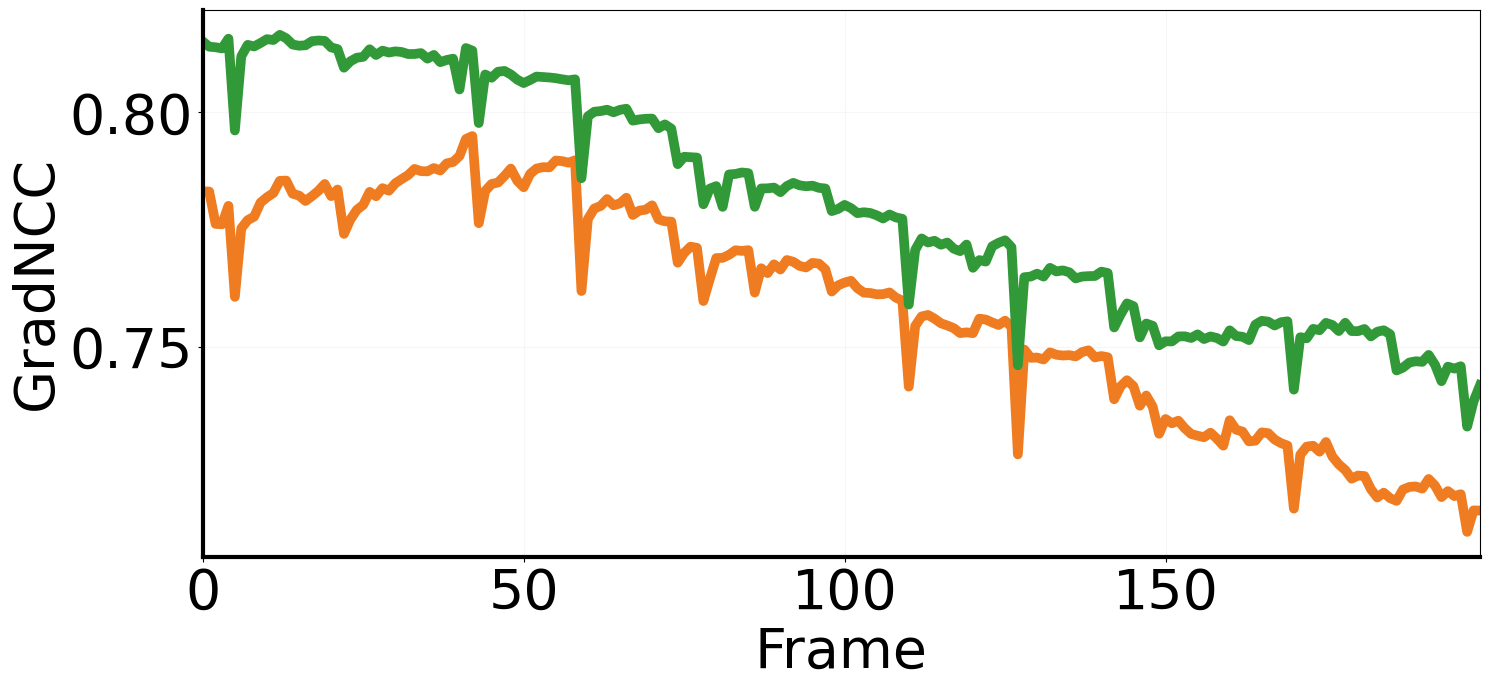

Saved to membrane_GradNCC_GM_vs_PPv2.pdf


In [32]:
# ================================================================
# Figure 2: Membrane GradNCC — GM vs PP v2
# ================================================================
c_gm = "#ef7c21"   # orange
c_pp = "#329939"   # green

fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(frames, df_gm["mem_GradNCC"], color=c_gm, lw=7.0)
ax.plot(frames, df_pp["mem_GradNCC"], color=c_pp, lw=7.0)

ax.set_ylabel("GradNCC", fontsize=40)
ax.set_xlabel("Frame", fontsize=40)
ax.tick_params(axis="both", labelsize=40)
ax.grid(True, alpha=0.1)
ax.set_xlim(0, 199)
ax.spines["bottom"].set_linewidth(3.0)
ax.spines["left"].set_linewidth(3.0)
fig.tight_layout()
fig.savefig(str(OUT_DIR / "membrane_GradNCC_GM_vs_PPv2.pdf"), bbox_inches="tight")
plt.show()
print("Saved to membrane_GradNCC_GM_vs_PPv2.pdf")